TODO:
- Grafiek correlatie neerslag en sensorwaarde op meerdere dieptes
- Grafiek effect van neerslag op waarde sensor (verschillende sensoren, zelfde diepte)
- Grafiek effect van neerslag op waarde sensor (Zelfde sensor, andere dieptes. Vergelijk verschillende sensoren om patroon te valideren)
- Grafiek gedrag sensorwaarden op meerdere dieptes
- Excel-bestand maken voor toezichthouders om in te vullen
- Interpretaties statistisch bewijzen

NICE TO HAVE:
- Grafieken parameteriseren op basis van dim tabel is_active en last_placement_date

INACTIVE:
- Betrouwbare weerdata vinden (Neerslagdata van KNMI is prima, maar met een tijd lag)


De handleiding van de Firefly sensor met WET probes luidt as volgt:
"De permittiviteit is een maat voor het watergehalte (100% water is gelijk aan een permittiviteit meting van 82).
Permitiviteit kan worden gebruikt om het watergehalte te vergelijken bij het vergelijken van metingen tussen identieke
media/substraten.
De Poseidon sensormetingen zijn gecompenseerd naar 25 Celsius.

De Poseidon EC-sensor meet de "bulk" EC in niet-vloeibare media (zoals substraten/bodems). De "poriewater-EC" moet
worden berekend op basis van een gekalibreerde formule, afhankelijk van het specifieke medium dat wordt gebruikt. De
EC van verschillende media kan niet worden vergeleken. Bijvoorbeeld: de EC van vloeibare media (fertigatie- en
irrigatiewater) kan niet vergeleken worden met EC-metingen van substraat- of bodemmedia. Het specifieke medium
beïnvloedt de EC-meting en kan alleen (op een volledig correcte wijze) vergeleken worden met EC-metingen die in
hetzelfde medium zijn uitgevoerd.
EC-metingen zijn temperatuurafhankelijk, dus metingen kunnen alleen vergeleken worden als ze bij dezelfde temperatuur
gemeten worden (correlatie is +/- 2% per graad Celsius) of als de metingen temperatuur gecompenseerd zijn.
De Poseidon sensormetingen zijn gecompenseerd naar 25 Celsius."

Uit bovenstaande alinea is af te leiden dat temperatuur niet meegenomen hoeft te worden in de analyse, omdat de data hierop reeds is
gecompenseerd.
_Electric conductivity_ (EC) is een meting van de hoeveelheid zouten in de grond. Voor landbouw kan dit interessante data zijn als een marker voor de hoeveelheid voeding in de bodem. Zoals boven gesteld kan deze data alleen vergeleken worden tussen sensoren in zeer gecontroleerde omstandigheden, wat niet het geval is in dit project. Er kan zodoende niks gezegd worden over de voeding present in de gemeten bodem. Andere toepassingen van deze data zijn op het moment niet duidelijk.
Permittiviteit is een marker voor de hoeveelheid water in de bodem. Aangezien de permittiviteit van water 82 farad per meter is, betekent deze waarde dat 100% van het materiaal waar de probe in staat uit water bestaat. Aangezien het hoofddoel van dit project is om de hoeveelheid vocht in de bodem te meten, is dit nuttige data.

Het primaire doel van fase twee van het _Leiden Water in the Cloud_ project is om de resultaten van fase 1 te valideren met meer geavanceerde sensoren. Een secundair doel is om een betere methode te vinden om een grenswaarde te bepalen.
Allereerst zal dus gevalideerd worden of de patronen gevonden in fase 1 ook terug te zien zijn in de data van fase twee. Hierbij moet wel vermeld worden dat de probes van de nieuwe sensoren op minimaal 15cm onder de grond liggen, maar de probes in fase 1 minimaal 30 centimeter onder de grond liggen.
Desalniettemin is ervoor gekozen om deze twee dieptes met elkaar te vergelijken, in plaats van de probes op 50cm te gebruiken van de nieuwe sensoren. Het idee hierachter is dat de probes dichter bij het oppervlak sterkere patronen laten zien dan die op 50cm diep, en daarmee beter geschikt zijn voor het valideren van de eerdere patronen gezien in fase 1.
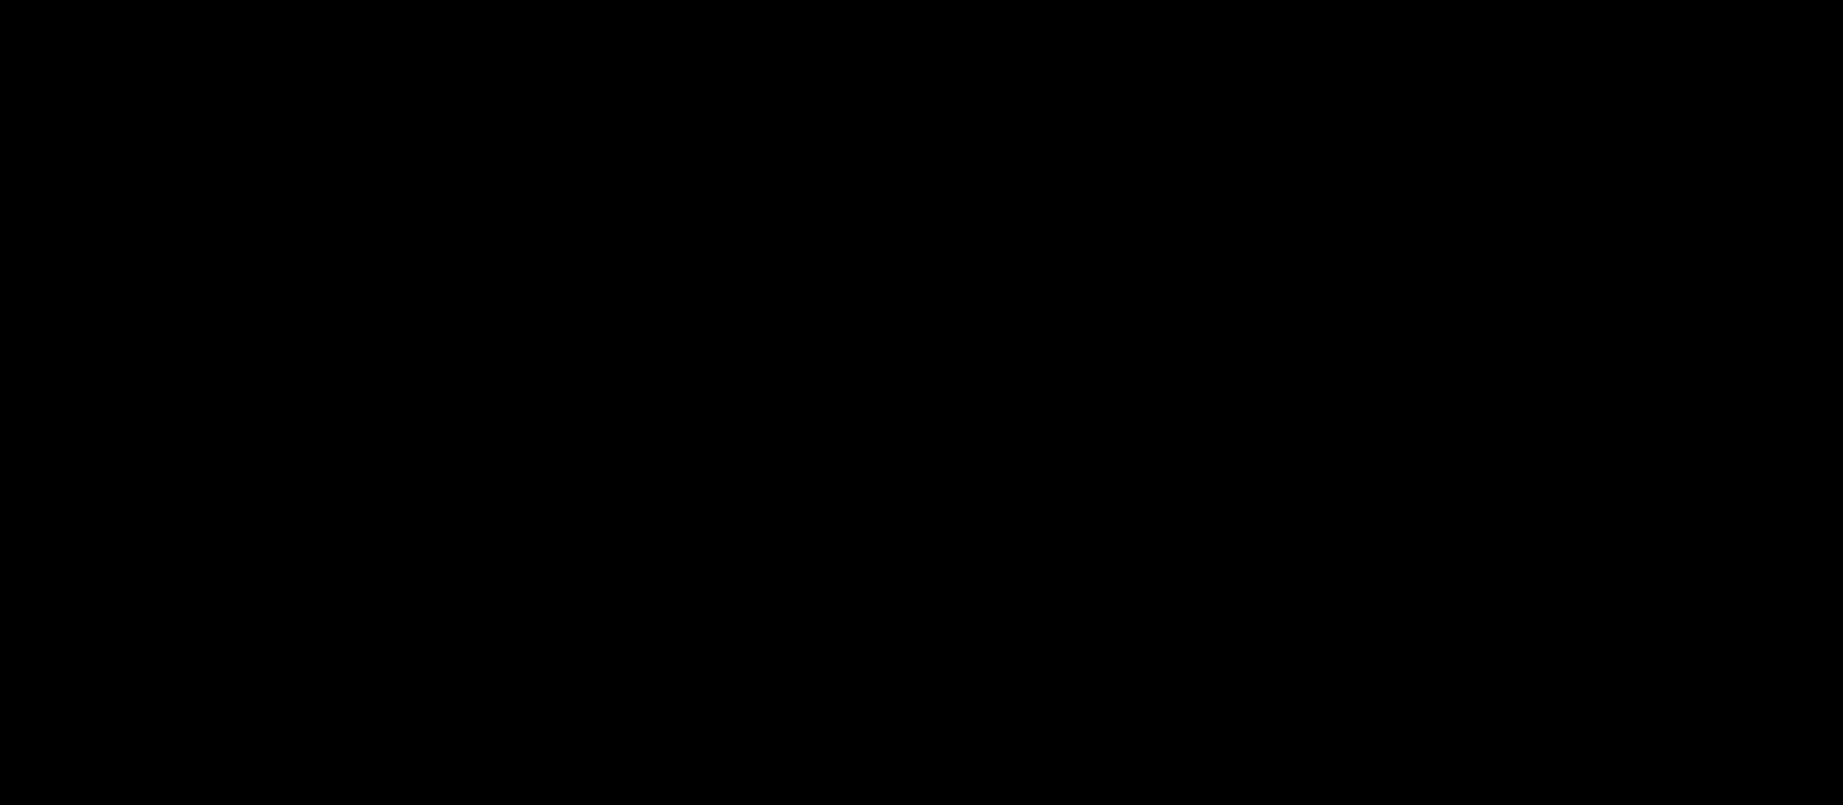
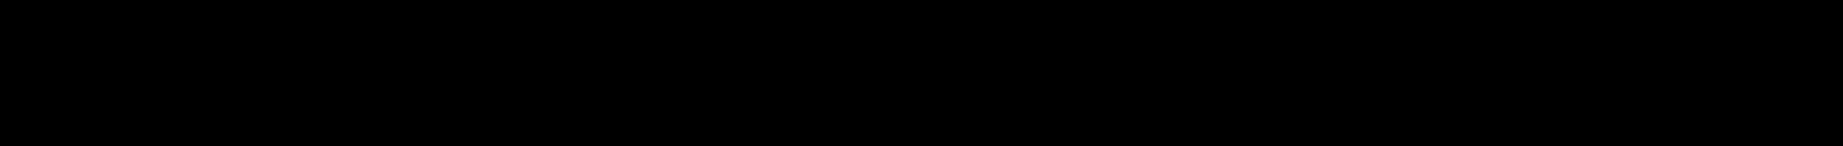

In [3]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [4]:
# Set graph parameters
device_ids = [360,399,1385,1387,1390,1391,1392,1393,1432] # 1384 en 1386 zijn inactief
date_from = '2025-07-18'
date_to = '2025-08-20'

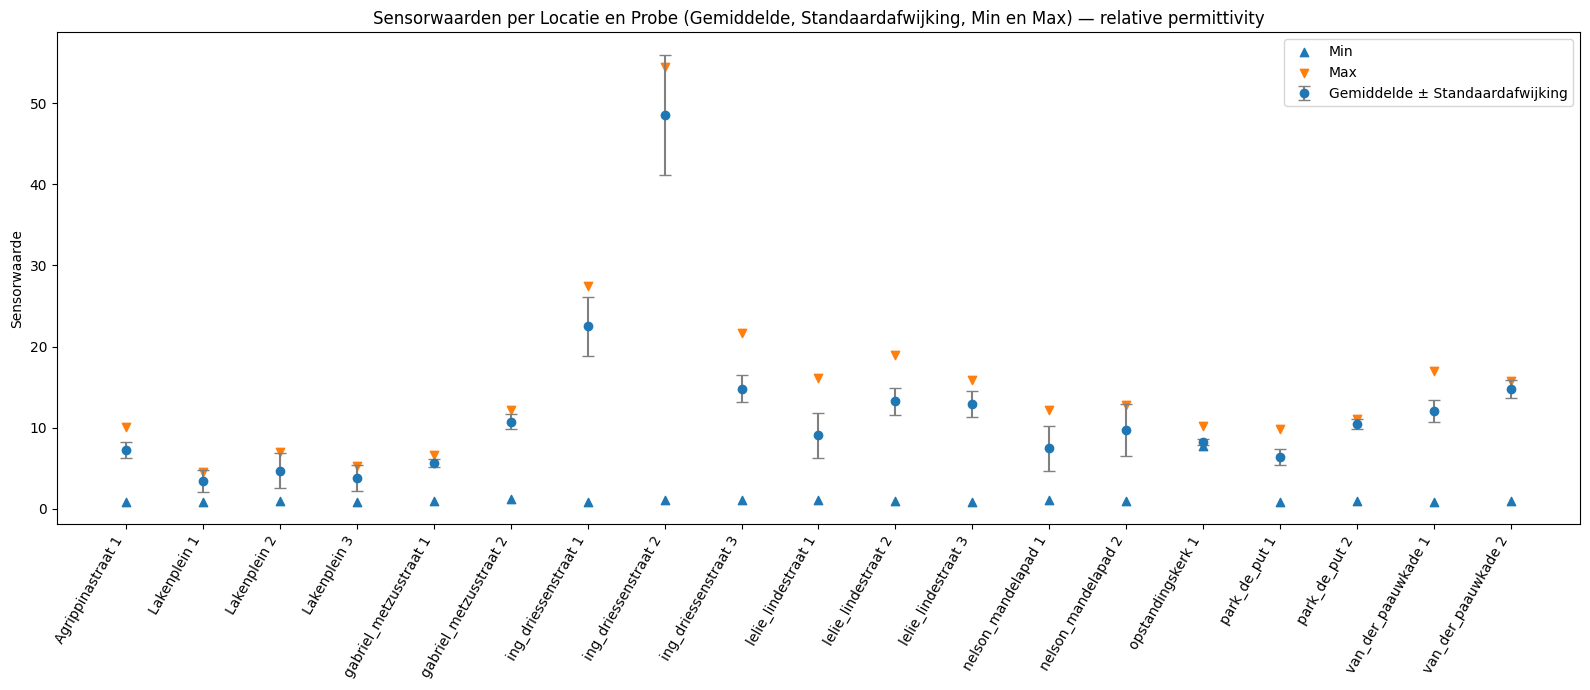

In [7]:
"""
De gemiddelde waardes en hun afwijkingen voor alle locaties en probes
"""

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Connect & query ---
conn = sqlite3.connect("multi_probe_data/database.db")

device_ids_str = ",".join(map(str, device_ids))  # unchanged

query = f"""
SELECT
    F.device_id,
    D.location_name,
    F.probe_number,
    F.relative_permittivity
FROM FactSensorData F
LEFT JOIN DimSensor D
    ON F.device_id = D.device_id
WHERE F.device_id IN ({device_ids_str})
ORDER BY D.location_name, F.probe_number;
"""
df = pd.read_sql_query(query, conn)
conn.close()

# --- Compute stats per (location, probe) ---
stats = (
    df.groupby(["location_name", "probe_number"])["relative_permittivity"]
      .agg(mean="mean", std="std", min="min", max="max")
      .reset_index()
      .sort_values(["location_name", "probe_number"], kind="stable")
)

# Some groups may have a single sample -> std = NaN; replace with 0 so error bars render
stats["std"] = stats["std"].fillna(0)

means = stats["mean"].to_numpy()
stds  = stats["std"].to_numpy()
mins  = stats["min"].to_numpy()
maxs  = stats["max"].to_numpy()

# X axis: one tick per (location, probe)
labels = [f"{loc} {probe}" for loc, probe in zip(stats["location_name"], stats["probe_number"])]
x = np.arange(len(labels))

# --- Plot ---
plt.figure(figsize=(16, 7))

# Mean ± std
plt.errorbar(
    x, means, yerr=stds, fmt='o',
    ecolor='gray', elinewidth=1.5, capsize=4,
    label="Gemiddelde ± Standaardafwijking"
)

# Min / Max
plt.scatter(x, mins, marker='^', label='Min')
plt.scatter(x, maxs, marker='v', label='Max')

# Formatting
plt.xticks(x, labels, rotation=60, ha='right')
plt.ylabel("Sensorwaarde")
plt.title("Sensorwaarden per Locatie en Probe (Gemiddelde, Standaardafwijking, Min en Max) — relative permittivity")
plt.legend()
plt.tight_layout()
plt.show()

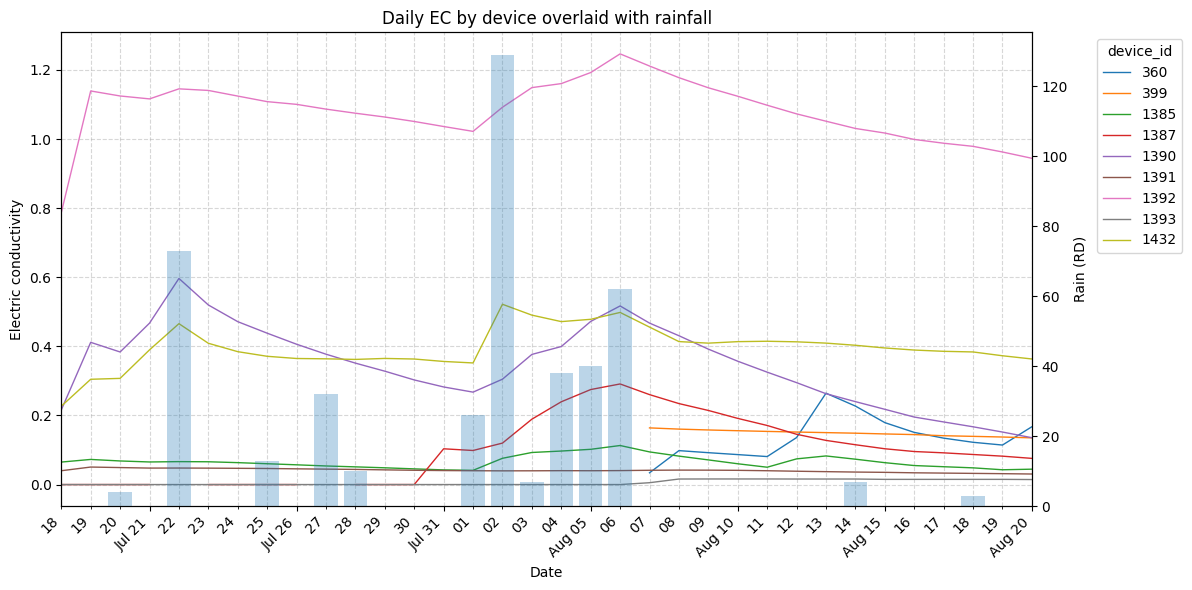

In [17]:
"""
Daily relative permittivity by device overlaid with rainfall in mm
"""

# Connect to the database
conn = sqlite3.connect("multi_probe_data/database.db")

# Query the data
device_ids = [360,399,1385,1387,1390,1391,1392,1393,1432]
device_ids_str = ",".join(map(str, device_ids))

query = f"""
SELECT
    F.device_id,
    D.location_name,
    F.relative_permittivity,
    F.timestamp
FROM FactSensorData F
LEFT JOIN DimSensor D
    ON F.device_id = D.device_id
WHERE F.device_id IN ({device_ids_str})
  AND probe_number = 1
ORDER BY location_name;
"""
sensor_df = pd.read_sql_query(query, conn)
conn.close()

# Aggregate sensor data by day
sensor_df['date'] = pd.to_datetime(sensor_df["timestamp"], unit="s").dt.date
sensor_mean_by_day_df = sensor_df.groupby(['device_id', 'date'])['relative_permittivity'].mean().reset_index()

# Import rain data
rain_df = pd.read_csv("multi_probe_data/valkenburg_precipitation.csv")
rain_df.columns = rain_df.columns.str.strip()

# Combine rain and sensor data
rain_df['date'] = pd.to_datetime(rain_df["DATE"]).dt.date
sensor_rain_df = pd.merge(sensor_mean_by_day_df, rain_df, on="date", how="left")

# Wide table: rows = date, columns = device_id, values = daily mean EC
ec_wide = (sensor_rain_df
           .pivot_table(index='date', columns='device_id',
                        values='relative_permittivity', aggfunc='mean')
           .sort_index())

# One rain value per day (drop duplicates caused by the merge)
rain = (sensor_rain_df[['date', 'RD']]
        .drop_duplicates(subset='date')
        .set_index('date')
        .sort_index()['RD'])

fig, ax1 = plt.subplots(figsize=(12,6))

# EC lines (one per device)
ec_wide.plot(ax=ax1, linewidth=1)
ax1.set_xlabel('Date')
ax1.set_ylabel('Electric conductivity')
ax1.set_title('Daily EC by device overlaid with rainfall')

# Limit x-axis
ax1.set_xlim(pd.to_datetime(date_from), pd.to_datetime(date_to))

# Major ticks every 5 days, minor ticks every day
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax1.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

# Format labels for ticks
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.xaxis.set_minor_formatter(mdates.DateFormatter("%d"))

# Rotate for readability
plt.setp(ax1.get_xticklabels(minor=False), rotation=45, ha="right")
plt.setp(ax1.get_xticklabels(minor=True), rotation=45, ha="right")

# Optional: gridlines
ax1.grid(which="both", linestyle="--", alpha=0.5)


# Rain bars on secondary axis
ax2 = ax1.twinx()
ax2.bar(rain.index, rain.values, alpha=0.3)  # daily bars
ax2.set_ylabel('Rain (RD)')

# Legend & layout
ax1.legend(title='device_id', bbox_to_anchor=(1.06, 1), loc='upper left')
plt.tight_layout()
plt.show()